# Property Address Classification Project

## Overview
This project aims to classify property addresses into specific categories using Machine Learning. The goal is to assist in organizing and tagging property data automatically.

## Categories
The addresses are classified into the following 5 categories:
1. `flat`
2. `houseorplot`
3. `landparcel`
4. `commercial unit`
5. `others`

## Approach
1. **Data Loading**: Load training and validation datasets.
2. **Data Preprocessing**: Clean text data (remove special characters, normalize case).
3. **Feature Extraction**: Use TF-IDF (Term Frequency-Inverse Document Frequency) to convert text to numerical vectors.
4. **Model Training**: Train a Logistic Regression model, which is effective for text classification tasks.
5. **Evaluation**: Evaluate the model using Accuracy, Precision, Recall, and F1-Score.
6. **Inference**: Demonstrate how to use the trained model for predicting new addresses.

In [1]:
# Install necessary libraries if not already installed
!pip install pandas numpy scikit-learn joblib matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Set plot style
sns.set(style='whitegrid')

## 1. Data Loading
We will load the training and validation datasets provided.

In [3]:
# File paths
TRAIN_DATA_PATH = 'task_dataset - training_dataset.csv'
VAL_DATA_PATH = 'task_dataset - validation_dataset.csv'

def load_data(path):
    try:
        df = pd.read_csv(path)
        print(f"Successfully loaded data from {path}")
        print(f"Shape: {df.shape}")
        return df
    except Exception as e:
        print(f"Error loading data from {path}: {e}")
        return None

# Load datasets
train_df = load_data(TRAIN_DATA_PATH)
val_df = load_data(VAL_DATA_PATH)

# Display first few rows
print("\nTraining Data Sample:")
display(train_df.head())

Successfully loaded data from task_dataset - training_dataset.csv
Shape: (8936, 2)
Successfully loaded data from task_dataset - validation_dataset.csv
Shape: (2681, 2)

Training Data Sample:


,property_address,categories
0,"New Ppid 1Kqttmg7, House, Property Id No.58C57...",houseorplot
1,"Property Of Rs No.12/2,Plot No. 01,House Numbe...",houseorplot
2,"Flat-504,Floor-5 Shanti Vista-Ii Wing C Bldg 9...",flat
3,"Flat-103,Floor-1 Eshamya Florenza Tower L S No...",flat
4,Flat No G 532 I P Extension Patparganj 2Nd Flo...,flat


## 2. Exploratory Data Analysis (EDA)
Let's look at the distribution of categories in the training set.

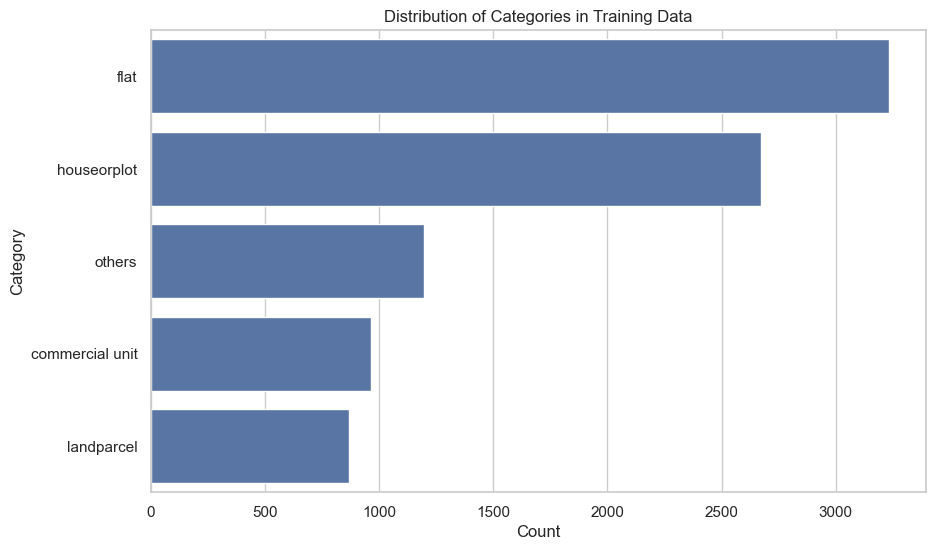

categories
flat               3232
houseorplot        2673
others             1197
commercial unit     965
landparcel          869
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(y='categories', data=train_df, order=train_df['categories'].value_counts().index)
plt.title('Distribution of Categories in Training Data')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

print(train_df['categories'].value_counts())

## 3. Data Preprocessing
Text data needs to be cleaned before feeding it into the model. We will:
- Convert text to lowercase.
- Remove special characters and punctuation.
- Remove extra whitespace.

In [5]:
def preprocess_text(text):
    """Clean and preprocess text."""
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove special characters and digits (keep only alphabets and spaces for simplicity)
    # Note: Depending on the address format, keeping numbers might be beneficial, 
    # but for this baseline, we'll focus on text patterns.
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
train_df['clean_text'] = train_df['property_address'].apply(preprocess_text)
val_df['clean_text'] = val_df['property_address'].apply(preprocess_text)

# Show before and after
print("Preprocessing Example:")
print(train_df[['property_address', 'clean_text']].head())

Preprocessing Example:
                                    property_address  \
0  New Ppid 1Kqttmg7, House, Property Id No.58C57...   
1  Property Of Rs No.12/2,Plot No. 01,House Numbe...   
2  Flat-504,Floor-5 Shanti Vista-Ii Wing C Bldg 9...   
3  Flat-103,Floor-1 Eshamya Florenza Tower L S No...   
4  Flat No G 532 I P Extension Patparganj 2Nd Flo...   

                                          clean_text  
0  new ppid kqttmg house property id no c u havin...  
1  property of rs no plot no house number e swatt...  
2  flat floor shanti vista ii wing c bldg s no wi...  
3  flat floor eshamya florenza tower l s no rs b ...  
4  flat no g i p extension patparganj nd floor ag...  


## 4. Model Training

We will use a **Pipeline** that consists of:
1. **TfidfVectorizer**: Converts the text documents to a matrix of TF-IDF features.
2. **LogisticRegression**: A robust linear model for classification.

We use `class_weight='balanced'` to handle potential class imbalances.

In [6]:
# Prepare features and labels
X_train = train_df['clean_text']
y_train = train_df['categories']
X_val = val_df['clean_text']
y_val = val_df['categories']

# Create Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Train the model
print("Training model...")
pipeline.fit(X_train, y_train)
print("Model training complete.")

Training model...
Model training complete.


## 5. Evaluation
We evaluate the model on the validation set using accuracy, classification report, and confusion matrix.

Validation Accuracy: 0.8683

Classification Report:
                 precision    recall  f1-score   support

commercial unit       0.91      0.94      0.93       290
           flat       0.96      0.89      0.92       970
    houseorplot       0.90      0.83      0.87       802
     landparcel       0.75      0.86      0.80       260
         others       0.68      0.85      0.75       359

       accuracy                           0.87      2681
      macro avg       0.84      0.87      0.85      2681
   weighted avg       0.88      0.87      0.87      2681



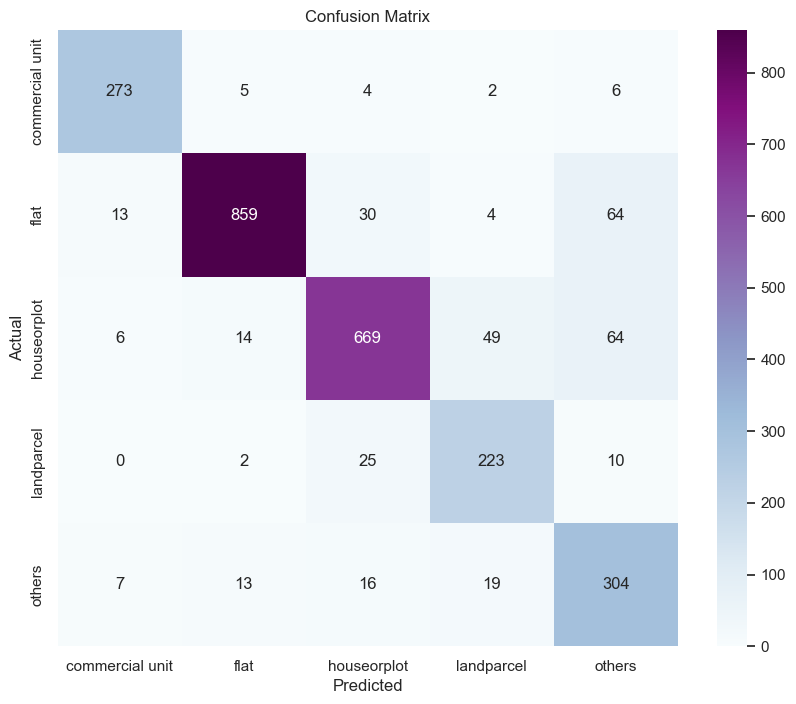

In [15]:
# Predict on validation set
y_pred = pipeline.predict(X_val)

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 6. Saving the Model
We save the trained pipeline (which includes both the vectorizer and the classifier) to a file for future use.

In [8]:
MODEL_DIR = 'best_model'
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, 'property_classifier.pkl')

joblib.dump(pipeline, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to best_model\property_classifier.pkl


## 7. Inference Example
Here is how to load the model and make predictions on new data.

In [9]:
# Load the model
loaded_model = joblib.load(MODEL_PATH)

# Sample addresses to test
sample_addresses = [
    "Flat No 302, Sunshine Apartments, MG Road",
    "Plot No 45, Green Valley Layout",
    "Shop No 12, City Center Mall",
    "Survey No 123/2, Agricultural Land near Highway",
    "Some random text that might fall into others"
]

# Preprocess samples
clean_samples = [preprocess_text(addr) for addr in sample_addresses]

# Predict
predictions = loaded_model.predict(clean_samples)

# Display results
for addr, pred in zip(sample_addresses, predictions):
    print(f"Address: {addr}\nPrediction: {pred}\n{'-'*30}")

Address: Flat No 302, Sunshine Apartments, MG Road
Prediction: flat
------------------------------
Address: Plot No 45, Green Valley Layout
Prediction: houseorplot
------------------------------
Address: Shop No 12, City Center Mall
Prediction: commercial unit
------------------------------
Address: Survey No 123/2, Agricultural Land near Highway
Prediction: landparcel
------------------------------
Address: Some random text that might fall into others
Prediction: others
------------------------------
